In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [3]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [4]:
df.shape

(1470, 35)

In [5]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [7]:
df.shape

(1470, 35)

In [8]:
df["Attrition"].value_counts()

,count
Attrition,
No,1233
Yes,237


In [9]:
attrition_rate = (df["Attrition"].value_counts(normalize=True) * 100)

print(attrition_rate)

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


In [10]:
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

categorical_columns = df.select_dtypes(include=['object']).columns

print("Numeric Columns:", len(numeric_columns))
print("Categorical Columns:", len(categorical_columns))

Numeric Columns: 26
Categorical Columns: 9


In [11]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [12]:
df = df.drop(columns=["EmployeeNumber", "Over18", "StandardHours"])

In [13]:
df.shape

(1470, 32)

In [14]:
df["Attrition"] = df["Attrition"].map({"Yes": 1, "No": 0})

In [15]:
df["Attrition"].head(10)

,Attrition
0,1
1,0
2,1
3,0
4,0
5,0
6,0
7,0
8,0
9,0


In [16]:
df = pd.get_dummies(df, drop_first=True)

In [17]:
df.shape

(1470, 46)

In [18]:
df.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,1,2,94,3,2,...,False,False,False,False,False,True,False,False,True,True
1,49,0,279,8,1,1,3,61,2,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,1,4,92,2,1,...,True,False,False,False,False,False,False,False,True,True
3,33,0,1392,3,4,1,4,56,3,1,...,False,False,False,False,True,False,False,True,False,True
4,27,0,591,2,1,1,1,40,3,1,...,True,False,False,False,False,False,False,True,False,False


In [19]:
from sklearn.preprocessing import StandardScaler

In [20]:
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

In [21]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [22]:
X_scaled.shape

(1470, 45)

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
df_eda = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

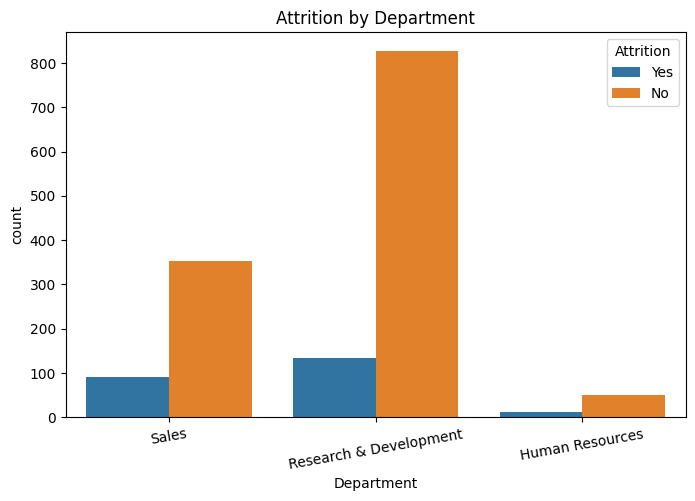

In [25]:
plt.figure(figsize=(8,5))

sns.countplot(data=df_eda, x="Department", hue="Attrition")

plt.title("Attrition by Department")
plt.xticks(rotation=10)

plt.show()

Research & Development has the highest number of employees and also the highest number of employees leaving the company. Human Resources has the lowest attrition count. Sales also shows a noticeable number of employees leaving.

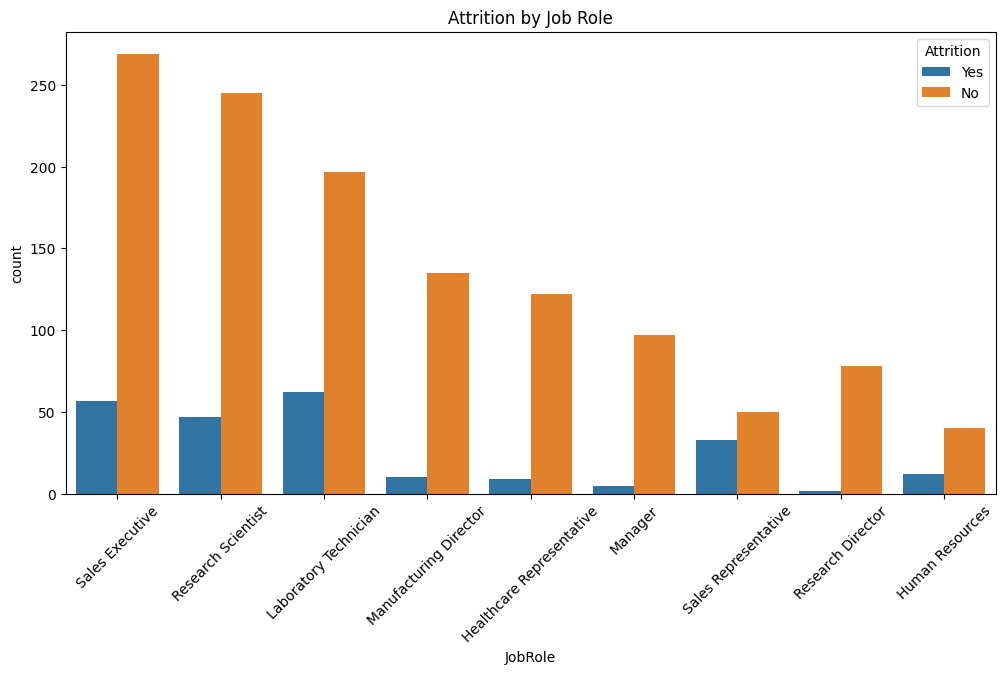

In [26]:
plt.figure(figsize=(12,6))

sns.countplot(data=df_eda, x="JobRole", hue="Attrition")

plt.title("Attrition by Job Role")

plt.xticks(rotation=45)

plt.show()

Employees in certain job roles show higher attrition than others. HR should focus retention efforts on the roles with the highest employee exits.

Sales Executives, Laboratory Technicians, and Research Scientists show the highest number of employee exits. HR should prioritize retention strategies for these job roles.

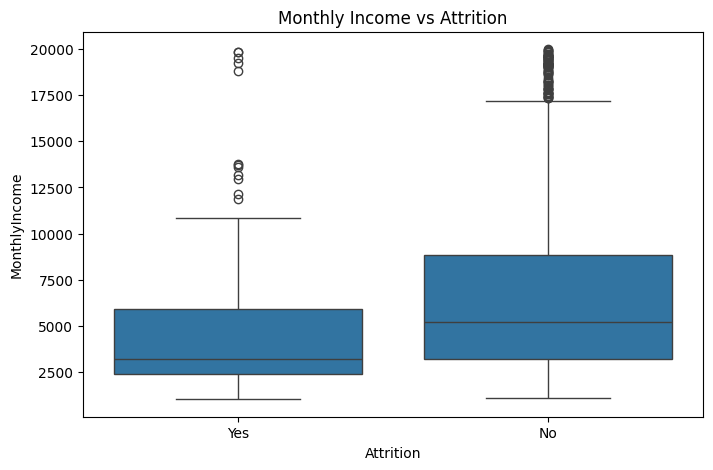

In [27]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df_eda, x="Attrition", y="MonthlyIncome")

plt.title("Monthly Income vs Attrition")

plt.show()

Employees with lower monthly income tend to show higher attrition compared to employees with higher monthly income.

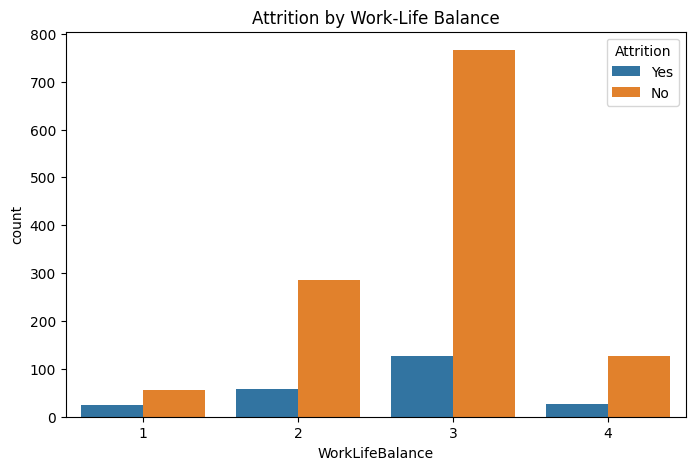

In [28]:
plt.figure(figsize=(8,5))

sns.countplot(data=df_eda, x="WorkLifeBalance", hue="Attrition")

plt.title("Attrition by Work-Life Balance")

plt.show()

Employees with lower Work-Life Balance ratings tend to leave the company more often than employees with better work-life balance.

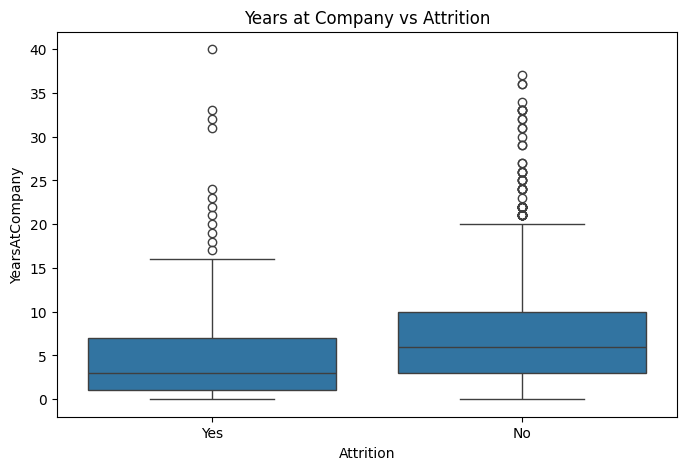

In [29]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df_eda, x="Attrition", y="YearsAtCompany")

plt.title("Years at Company vs Attrition")

plt.show()

Employees with fewer years at the company are more likely to leave than long-term employees.

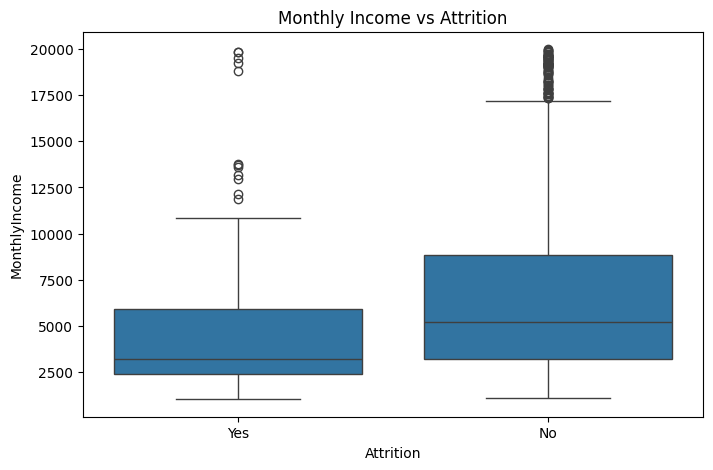

In [30]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df_eda, x="Attrition", y="MonthlyIncome")

plt.title("Monthly Income vs Attrition")

plt.show()

Employees with lower monthly income tend to have higher attrition compared to employees with higher monthly income.

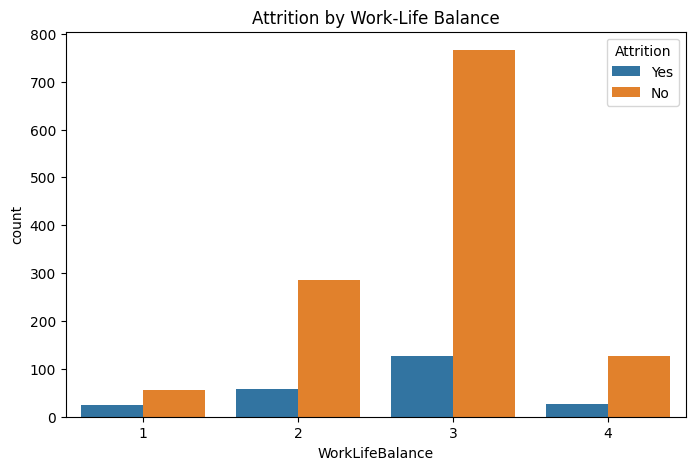

In [31]:
plt.figure(figsize=(8,5))

sns.countplot(data=df_eda, x="WorkLifeBalance", hue="Attrition")

plt.title("Attrition by Work-Life Balance")

plt.show()

Employees with lower Work-Life Balance ratings are more likely to leave the company

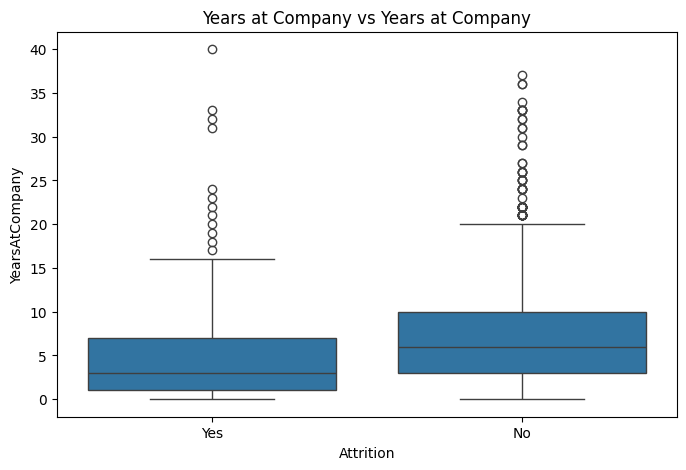

In [32]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df_eda, x="Attrition", y="YearsAtCompany")

plt.title("Years at Company vs Years at Company")

plt.show()

Employees who have spent fewer years at the company show a higher tendency to leave.

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (1176, 45)
Testing Data: (294, 45)


In [34]:
from sklearn.linear_model import LogisticRegression

In [35]:
model_lr = LogisticRegression(class_weight="balanced", random_state=42)

In [36]:
model_lr.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', random_state=42)

In [37]:
y_pred_lr = model_lr.predict(X_test)

In [38]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [39]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.91      0.77      0.84       247
           1       0.34      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.77       294



In [40]:
cm = confusion_matrix(y_test, y_pred_lr)
print(cm)

[[191  56]
 [ 18  29]]


In [41]:
y_prob_lr = model_lr.predict_proba(X_test)[:,1]

roc = roc_auc_score(y_test, y_prob_lr)

print("ROC-AUC Score:", roc)

ROC-AUC Score: 0.798604530967353


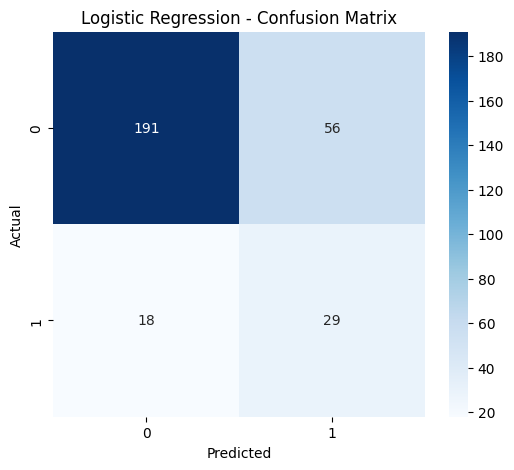

In [42]:
plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")

plt.show()

In [43]:
from sklearn.ensemble import RandomForestClassifier

In [44]:
model_rf = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)

In [45]:
model_rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [46]:
y_pred_rf = model_rf.predict(X_test)

In [47]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.85      0.99      0.91       247
           1       0.50      0.06      0.11        47

    accuracy                           0.84       294
   macro avg       0.67      0.53      0.51       294
weighted avg       0.79      0.84      0.78       294



In [48]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_rf)

[[244   3]
 [ 44   3]]


In [49]:
y_prob_rf = model_rf.predict_proba(X_test)[:,1]

roc_rf = roc_auc_score(y_test, y_prob_rf)

print("ROC-AUC Score:", roc_rf)

ROC-AUC Score: 0.7752175036609527


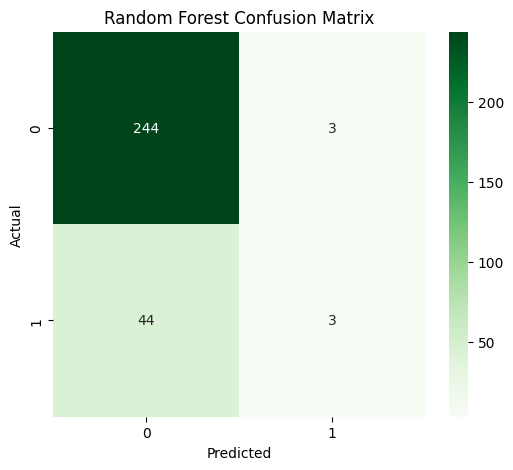

In [50]:
plt.figure(figsize=(6,5))

sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [51]:
from sklearn.ensemble import GradientBoostingClassifier

In [52]:
model_gb = GradientBoostingClassifier(random_state=42)

In [53]:
model_gb.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [54]:
y_pred_gb = model_gb.predict(X_test)

In [55]:
print(classification_report(y_test, y_pred_gb))

              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.61      0.23      0.34        47

    accuracy                           0.85       294
   macro avg       0.74      0.60      0.63       294
weighted avg       0.83      0.85      0.83       294



In [56]:
cm_gb = confusion_matrix(y_test, y_pred_gb)

print(cm_gb)

[[240   7]
 [ 36  11]]


In [57]:
y_prob_gb = model_gb.predict_proba(X_test)[:,1]

roc_gb = roc_auc_score(y_test, y_prob_gb)

print("ROC-AUC Score:", roc_gb)

ROC-AUC Score: 0.7937806873977087


In [58]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "ROC-AUC Score": [
        roc,
        roc_rf,
        roc_gb
    ]
})

comparison

,Model,ROC-AUC Score
0,Logistic Regression,0.798605
1,Random Forest,0.775218
2,Gradient Boosting,0.793781


In [59]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
10,MonthlyIncome,0.071443
0,Age,0.061937
17,TotalWorkingYears,0.054522
1,DailyRate,0.051280
11,MonthlyRate,0.047951
23,YearsWithCurrManager,0.046725
20,YearsAtCompany,0.046042
44,OverTime_Yes,0.043751
6,HourlyRate,0.043070
2,DistanceFromHome,0.042327


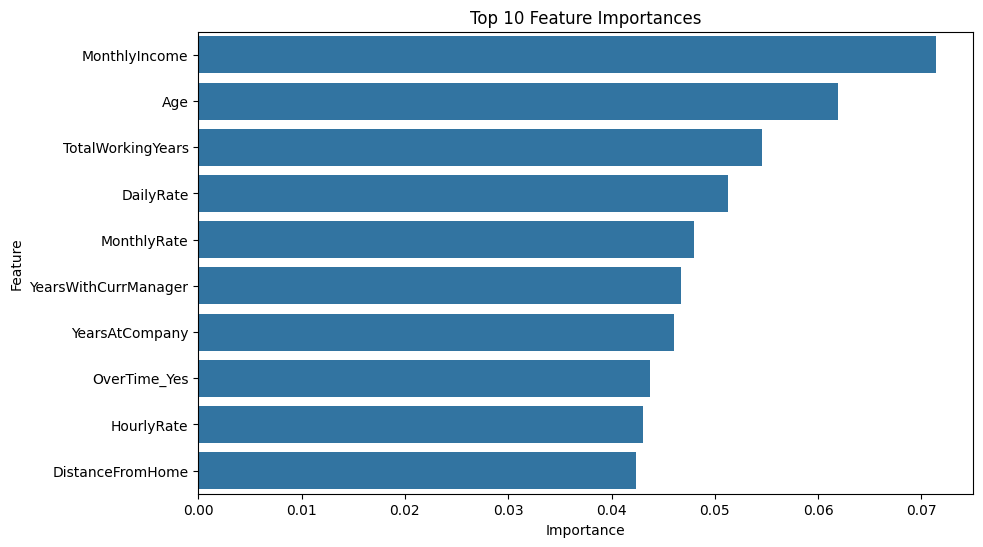

In [60]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importances")

plt.show()

# Task 7 - HR Insights & Business Recommendations

## Key Findings

- Monthly Income is the most important factor affecting employee attrition.
- Younger employees and employees with fewer total working years are more likely to leave.
- Overtime and years at the company also influence attrition.

## Departments to Prioritize

Research & Development and Sales departments should be the primary focus for employee retention efforts.

## Does Salary Alone Explain Attrition?

No. Salary is important, but work-life balance, overtime, experience, and years at the company also play a significant role.

## HR Recommendations

1. Improve work-life balance and reduce overtime for high-risk employees.
2. Provide career growth opportunities and regular salary reviews for employees with lower experience and income.

## Model Limitation

This model is based on historical HR data. It cannot consider personal reasons or future business changes, so it should be used as a decision-support tool rather than the only basis for HR decisions.